In [ ]:
%%capture
!unset LD_PRELOAD
import os
os.environ.pop('LD_PRELOAD', None)

In [2]:
%%bash 
pip install uv
uv pip install jupyter matplotlib numpy pandas torch==2.5.0 torchviz gymnasium engression stable-baselines3

# setup osmesa cpu backend for mujoco
conda install -c conda-forge mesalib
export MUJOCO_GL=osmesa
export PYOPENGL_PLATFORM=osmesa

Using Python 3.11.10 environment at: /opt/conda
Resolved 133 packages in 559ms
Uninstalled 14 packages in 846ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 18 packages in 25.77s
 + engression==0.1.12
 - nvidia-cublas-cu12==12.3.4.1
 + nvidia-cublas-cu12==12.4.5.8
 - nvidia-cuda-cupti-cu12==12.3.101
 + nvidia-cuda-cupti-cu12==12.4.127
 - nvidia-cuda-nvrtc-cu12==12.3.107
 + nvidia-cuda-nvrtc-cu12==12.4.127
 - nvidia-cuda-runtime-cu12==12.3.101
 + nvidia-cuda-runtime-cu12==12.4.127
 - nvidia-cudnn-cu12==8.9.7.29
 + nvidia-cudnn-cu12==9.1.0.70
 - nvidia-cufft-cu12==11.0.12.1
 + nvidia-cufft-cu12==11.2.1.3
 - nvidia-curand-cu12==10.3.4.107
 + nvidia-curand-cu12==10.3.5.147
 - nvidia-cusolver-cu12==11.5.4.101
 + nvidia-cusolver-cu12==11.6.1.9
 - nvidia-cusparse-cu12==12.2.0.103
 + nvidia-cusparse-cu12==1

Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done




==> WARNING: A newer version of conda exists. <==
    current version: 24.9.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda





## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - mesalib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blas-2.136                 |         openblas          17 KB  conda-forge
    blas-devel-3.9.0           |36_h1ea3ea9_openblas          17 KB  conda-forge
    ca-certificates-2025.8.3   |       hbd8a1cb_0         151 KB  conda-forge
    certifi-2025.8.3           |     pyhd8ed1ab_0         155 KB  conda-forge
    expat-2.7.1                |       hecca717_0         138 KB  conda-forge
    libblas-3.9.0              |36_h4a7cf45_openblas          17 KB  conda-forge
    libcblas-3.9.0             |36_h0358290_openblas          17 KB  conda-forge
    libdrm-2.4.125             |       hb03c661_1         304 KB  conda-forge
    libexpat-2.7.1             |       hecca717_0          73 KB  conda-forge
    libgcc-15.1.0              |       h767d61c

In [ ]:
# vectorized environments (parallel training on multiple envs) --> https://gymnasium.farama.org/tutorials/training_agents/vector_a2c/

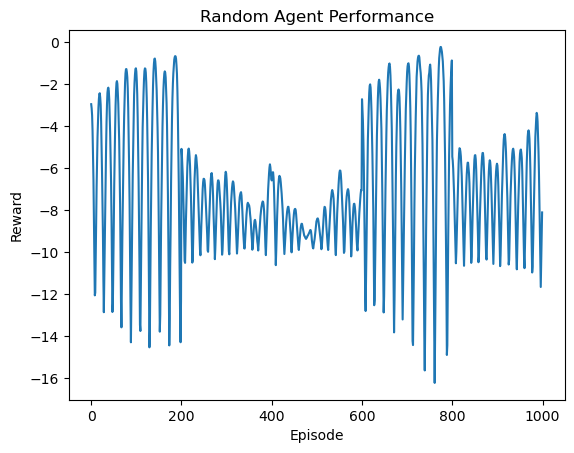

In [3]:

import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array", g=10.0)
observation, info = env.reset(seed=42)

rewards = []
trajectories = []
for _ in range(1000):
    current_state = observation
    action = env.action_space.sample()  
    # current_action = action
    observation, reward, terminated, truncated, info = env.step(action)
    next_state = observation

    rewards.append(reward)
    trajectories.append((current_state, action, reward, next_state))



    if terminated or truncated:
        observation, info = env.reset()

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

In [4]:
trajectories[0]

(array([-0.14995256,  0.9886932 , -0.12224312], dtype=float32),
 array([1.0200857], dtype=float32),
 -2.9654658160598943,
 array([-0.18800917,  0.98216724,  0.77228963], dtype=float32))

# Benchmark Generalization between MLPs and Engression Networks on Control Tasks

- use a CEM or MPC planner with a learned dynamics model to simulate trajectories and select the next best action (instead of training a policy)
    - rationale: planning is heavily reliant on the accuracy of the learned dynamics model, so if the dynamics model is not accurate, planning will fail

## Benchmark accross several environments
- Pendulum-v1
    - modify the gravity of the Pendulum-v1 environment to see if the model can adapt
    - bias the torque / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different gravity settings (6.0, 8.0, 12.0, 14.0) and different torque bias settings (0.0, 0.5, 1.0)

- CartPole-v1
    - modify the length of the pole to see if the model can adapt
    - bias the force / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different pole length settings (0.5, 0.7, 1.3, 1.5) and different force bias settings (0.0, 0.5, 1.0)
    
- Acrobot-v1
    - modify the length of the links to see if the model can adapt
    - bias the torque / introduce noise to one direction to see if the model can adapt
    - properly train until convergence, structure MLPs similar to Engression Networks (comparable number of parameters)
    - report average return over 100 episodes for different link length settings (0.5, 0.7, 1.3, 1.5) and different torque bias settings (0.0, 0.5, 1.0)

In [23]:
import torch
import numpy as np  
import matplotlib.pyplot as plt
from torch import nn, optim
import matplotlib.pyplot as plt
from engression.loss_func import energy_loss, energy_loss_two_sample
from engression.utils import vectorize, cor, check_for_gpu, make_folder
from engression.models import StoNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

class EngressionWorldModel(nn.Module):
    def __init__(
            self, 
            state_dim, 
            action_dim,
            num_layer,
            hidden_dim,
            noise_dim,
            add_bn=True,
            out_act=False, 
            resblock=False,
    ):
        super(EngressionWorldModel, self).__init__()
        self.model = StoNet(
            in_dim=state_dim + action_dim,
            out_dim=state_dim,
            num_layer=num_layer,
            hidden_dim=hidden_dim,
            noise_dim=noise_dim,
            add_bn=add_bn,
            out_act=out_act,
            resblock=resblock,
        ).to(DEVICE)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)

Using device: cuda


In [42]:
world_model

EngressionWorldModel(
  (model): StoNet(
    (input_layer): StoLayer(
      (layer): Sequential(
        (0): Linear(in_features=12, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (out_act): ReLU(inplace=True)
    )
    (inter_layer): Sequential(
      (0): StoLayer(
        (layer): Sequential(
          (0): Linear(in_features=72, out_features=64, bias=True)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (out_act): ReLU(inplace=True)
      )
      (1): StoLayer(
        (layer): Sequential(
          (0): Linear(in_features=72, out_features=64, bias=True)
          (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (out_act): ReLU(inplace=True)
      )
    )
    (out_layer): Linear(in_features=64, out_features=3, bias=True)
  )
)

Epoch 0, Loss: 3.2309, E(|Y-Yhat|): 3.5949, E(|Yhat-Yhat'|): 0.7280
Epoch 10, Loss: 3.1363, E(|Y-Yhat|): 3.5295, E(|Yhat-Yhat'|): 0.7865
Epoch 20, Loss: 3.3240, E(|Y-Yhat|): 3.7635, E(|Yhat-Yhat'|): 0.8791
Epoch 30, Loss: 2.3644, E(|Y-Yhat|): 2.9372, E(|Yhat-Yhat'|): 1.1456
Epoch 40, Loss: 2.4614, E(|Y-Yhat|): 2.9933, E(|Yhat-Yhat'|): 1.0638
Epoch 50, Loss: 1.7272, E(|Y-Yhat|): 2.4024, E(|Yhat-Yhat'|): 1.3504
Epoch 60, Loss: 2.1311, E(|Y-Yhat|): 2.7910, E(|Yhat-Yhat'|): 1.3198
Epoch 70, Loss: 1.3708, E(|Y-Yhat|): 2.1120, E(|Yhat-Yhat'|): 1.4823
Epoch 80, Loss: 1.5488, E(|Y-Yhat|): 2.3263, E(|Yhat-Yhat'|): 1.5551
Epoch 90, Loss: 1.2719, E(|Y-Yhat|): 2.0313, E(|Yhat-Yhat'|): 1.5188
Epoch 100, Loss: 1.1550, E(|Y-Yhat|): 2.0283, E(|Yhat-Yhat'|): 1.7467
Epoch 110, Loss: 0.7664, E(|Y-Yhat|): 1.6130, E(|Yhat-Yhat'|): 1.6931
Epoch 120, Loss: 0.4402, E(|Y-Yhat|): 1.3635, E(|Yhat-Yhat'|): 1.8464
Epoch 130, Loss: 0.5036, E(|Y-Yhat|): 1.2773, E(|Yhat-Yhat'|): 1.5474
Epoch 140, Loss: 0.4488, E(|Y-Y

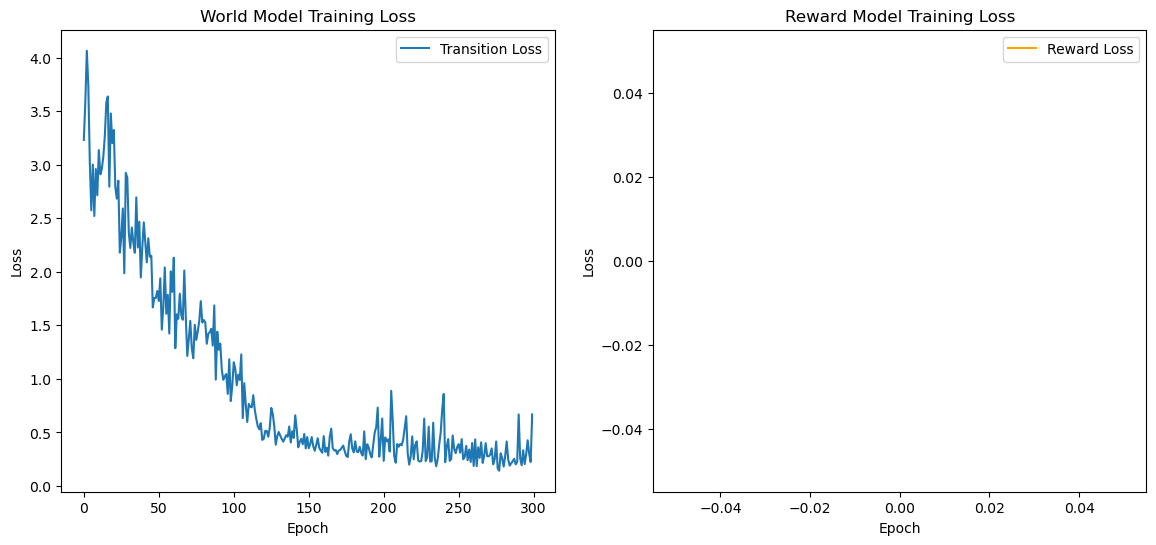

In [43]:
world_model = EngressionWorldModel(
    state_dim=3, 
    action_dim=1,
    num_layer=2,
    hidden_dim=64,
    noise_dim=32,
    add_bn=True,
    out_act=False,
    resblock=False,
).to(DEVICE)


# loss_fn = energy_loss_two_sample

#             for epoch_idx in range(self.num_epochs):
#                 self.model.zero_grad()
#                 y_sample1 = self.model(x)
#                 y_sample2 = self.model(x)
#                 loss, loss1, loss2 = energy_loss_two_sample(y, y_sample1, y_sample2, beta=self.beta, verbose=True)
#                 loss.backward()
#                 self.optimizer.step()
#                 if (epoch_idx == 0 or  (epoch_idx + 1) % print_every_nepoch == 0) and verbose:
#                     print("[Epoch {} ({:.0f}%)] energy-loss: {:.4f},  E(|Y-Yhat|): {:.4f},  E(|Yhat-Yhat'|): {:.4f}".format(
#                         epoch_idx + 1, 100 * epoch_idx / num_epochs, loss.item(), loss1.item(), loss2.item()))


# sample batch from trajectories
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        indices = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[idx] for idx in indices]
        state, action, reward, next_state = map(torch.stack, zip(*batch))
        return state, action, reward, next_state

    def batch_sample(self, batch_size):
        if len(self.buffer) < batch_size:
            return None
        return self.sample(batch_size)

replay_buffer = ReplayBuffer(capacity=10000)
def sample_from_replay_buffer(batch_size=64):
    return replay_buffer.batch_sample(batch_size)


optimizer = optim.Adam(world_model.parameters(), lr=1e-3)

# learn the transition dynamics
num_epochs = 300
batch_size = 64
losses = []
reward_losses = []
for epoch in range(num_epochs):
    for _ in range(64):  # Collect some data
        action = env.action_space.sample()
        noisy_action = action + np.random.normal(0, 2) + 1.1  # bias the torque to the right
        next_o, reward, done, truncated, info = env.step(noisy_action)
        # Store transition (o, action, reward, next_o)
        o = next_o
        replay_buffer.push(torch.tensor(o, dtype=torch.float32).to(DEVICE),
                           torch.tensor(action, dtype=torch.float32).to(DEVICE),
                           torch.tensor(reward, dtype=torch.float32).to(DEVICE),
                           torch.tensor(next_o, dtype=torch.float32).to(DEVICE))
        # store 
        if done or truncated:
            o, info = env.reset()

    world_model.zero_grad() # reset gradients
    states, actions, rewards, next_states = sample_from_replay_buffer(batch_size)
    y_sample1 = world_model(states, actions)
    y_sample2 = world_model(states, actions)
    loss, loss1, loss2 = energy_loss_two_sample(next_states, y_sample1, y_sample2, beta=1.0, verbose=True) # verbose to return all stats

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, E(|Y-Yhat|): {loss1.item():.4f}, E(|Yhat-Yhat'|): {loss2.item():.4f}")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(losses, label='Transition Loss')
ax[1].plot(reward_losses, label='Reward Loss', color='orange')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("World Model Training Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Reward Model Training Loss")
ax[0].legend()
ax[1].legend()
plt.show()

In [10]:
# object.__dict__

Using device: cuda
Epoch 10/300, Loss: 16.0653, Reward Loss: 58.1428
Epoch 20/300, Loss: 9.6674, Reward Loss: 43.7442
Epoch 30/300, Loss: 8.4516, Reward Loss: 54.2781
Epoch 40/300, Loss: 5.1016, Reward Loss: 53.8385
Epoch 50/300, Loss: 2.6520, Reward Loss: 45.6293
Epoch 60/300, Loss: 2.3559, Reward Loss: 40.7827
Epoch 70/300, Loss: 1.8960, Reward Loss: 27.6394
Epoch 80/300, Loss: 1.4840, Reward Loss: 16.1370
Epoch 90/300, Loss: 1.1666, Reward Loss: 12.5140
Epoch 100/300, Loss: 1.4299, Reward Loss: 15.1471
Epoch 110/300, Loss: 1.3743, Reward Loss: 11.9173
Epoch 120/300, Loss: 1.2931, Reward Loss: 9.9505
Epoch 130/300, Loss: 1.0653, Reward Loss: 9.7366
Epoch 140/300, Loss: 0.9112, Reward Loss: 8.6340
Epoch 150/300, Loss: 0.6836, Reward Loss: 5.7293
Epoch 160/300, Loss: 0.6247, Reward Loss: 5.2495
Epoch 170/300, Loss: 0.5790, Reward Loss: 5.3948
Epoch 180/300, Loss: 0.4837, Reward Loss: 4.4449
Epoch 190/300, Loss: 0.3336, Reward Loss: 3.8883
Epoch 200/300, Loss: 0.3843, Reward Loss: 3.728

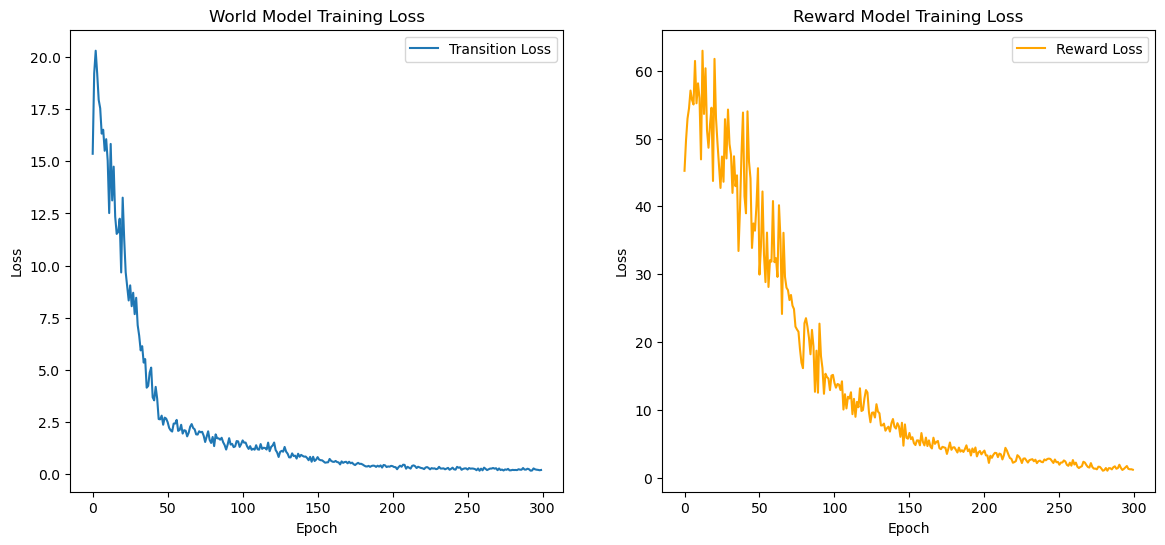

In [ ]:
import torch
import numpy as np
from torch import nn, optim 
import torch.functional as F
from engression import engression

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")





class WorldModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super(WorldModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, state_dim + 1)  # Predict next state and reward
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)

class RewardModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=16):
        super(RewardModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim + state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # Predict reward
        )
        self.model.to(DEVICE)
    
    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.capacity = capacity
        self.buffer = []
        self.position = 0
    
    def push(self, state, action, reward, next_state):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state)
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size=64):
        batch = torch.randperm(len(self.buffer))[:batch_size]
        state, action, reward, next_state = map(torch.stack, zip(*[self.buffer[i] for i in batch]))
        return state, action, reward, next_state
    
    def batch_sample(self, batch_size=64):
        # ensure we use Python ints for indexing and handle stored tensor elements correctly
        indices = torch.randperm(len(self.buffer))[:batch_size].tolist()
        states, actions, rewards, next_states = zip(*[self.buffer[idx] for idx in indices])
        # If the stored elements are already torch.Tensors, stack them directly.
        if isinstance(states[0], torch.Tensor):
            states = torch.stack(states).to(DEVICE)
            actions = torch.stack(actions).to(DEVICE)
            rewards = torch.stack(rewards).to(DEVICE)
            next_states = torch.stack(next_states).to(DEVICE)
        else:
            # fallback if numpy arrays were stored
            states = torch.tensor(states, dtype=torch.float32).to(DEVICE)
            actions = torch.tensor(actions, dtype=torch.float32).to(DEVICE)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(DEVICE)
            next_states = torch.tensor(next_states, dtype=torch.float32).to(DEVICE)
        return states, actions, rewards, next_states
    
    def __len__(self):
        return len(self.buffer)



env = gym.make("Pendulum-v1", render_mode="rgb_array", g=10.0)
o, info = env.reset(seed=42)

# init wm
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
world_model = WorldModel(state_dim, action_dim)
optimizer = optim.Adam(world_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# init reward model
reward_model = RewardModel(state_dim, action_dim)
reward_optimizer = optim.Adam(reward_model.parameters(), lr=0.001)
reward_loss_fn = nn.MSELoss()


def modified_step(self, u):
    '''Adding stochasticity from "wind" to the Pendulum environment'''
    def angle_normalize(x):
        return ((x + np.pi) % (2 * np.pi)) - np.pi
    
    th, thdot = self.state  # th := theta

    g = self.g
    m = self.m
    l = self.l
    dt = self.dt

    # add some biased noise to the action
    u += np.random.normal(0, 0.1) + 0.5  # bias the torque to the right

    u = np.clip(u, -self.max_torque, self.max_torque)[0]
    self.last_u = u  # for rendering
    costs = angle_normalize(th) ** 2 + 0.1 * thdot**2 + 0.001 * (u**2)

    newthdot = thdot + (3 * g / (2 * l) * np.sin(th) + 3.0 / (m * l**2) * u) * dt
    newthdot = np.clip(newthdot, -self.max_speed, self.max_speed)
    newth = th + newthdot * dt

    self.state = np.array([newth, newthdot])

    if self.render_mode == "human":
        self.render()
    # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
    return self._get_obs(), -costs, False, False, {}


# # bind the modified_step function to this env instance so `self` is passed automatically
# env.step = types.MethodType(modified_step, env)
# o, info = env.reset(seed=42)
# init buffer
replay_buffer = ReplayBuffer(capacity=10000)
def sample_from_replay_buffer(batch_size=64):
    return replay_buffer.batch_sample(batch_size)

# learn the transition dynamics
num_epochs = 300
batch_size = 64
losses = []
reward_losses = []
for epoch in range(num_epochs):
    for _ in range(64):  # Collect some data
        action = env.action_space.sample()
        noisy_action = action + np.random.normal(0, 2) + 1.1  # bias the torque to the right
        next_o, reward, done, truncated, info = env.step(noisy_action)
        # Store transition (o, action, reward, next_o)
        o = next_o
        replay_buffer.push(torch.tensor(o, dtype=torch.float32).to(DEVICE),
                           torch.tensor(action, dtype=torch.float32).to(DEVICE),
                           torch.tensor(reward, dtype=torch.float32).to(DEVICE),
                           torch.tensor(next_o, dtype=torch.float32).to(DEVICE))
        # store 
        if done or truncated:
            o, info = env.reset()


    # Sample a batch from the replay buffer
    states, actions, rewards, next_states = sample_from_replay_buffer(batch_size)

    # Train the world model
    preds = world_model(states, actions)
    loss = loss_fn(preds, torch.cat([next_states, rewards.unsqueeze(-1)], dim=-1))

    # Train the reward model
    reward_preds = reward_model(states, actions, next_states)
    reward_loss = reward_loss_fn(reward_preds, rewards.unsqueeze(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    reward_optimizer.zero_grad()
    reward_loss.backward()
    reward_optimizer.step()

    losses.append(loss.item())
    reward_losses.append(reward_loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Reward Loss: {reward_loss.item():.4f}")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].plot(losses, label='Transition Loss')
ax[1].plot(reward_losses, label='Reward Loss', color='orange')
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("World Model Training Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Reward Model Training Loss")
ax[0].legend()
ax[1].legend()

    def step(self, u):
        th, thdot = self.state  # th := theta

        g = self.g
        l = self.l
        m = self.m
        dt = self.dt

        u = np.clip(u, -self.max_torque, self.max_torque)[0]
        self.last_u = u  # for rendering
        costs = angle_normalize(th) ** 2 + 0.1 * thdot**2 + 0.001 * (u**2)

        newthdot = thdot + (3 * g / (2 * l) * np.sin(th) + 3.0 / (m * l**2) * u) * dt
        newthdot = np.clip(newthdot, -self.max_speed, self.max_speed)
        newth = th + newthdot * dt

        self.state = np.array([newth, newthdot])

        if self.render_mode == "human":
            self.render()
        # truncation=False as the time limit is handled by the `TimeLimit` wrapper added during `make`
        return self._get_obs(), -costs, False, False, {}

In [ ]:
class MPCPlanner(object):

    def __int__(
        self, 
        world_model,
        reward_model,
        current_state,
        action_space, 
        horizon=5,
        num_simulations=100, # number of action sequences to simulate from
        cost_func=None,
        device=DEVICE,
    ):
        super().__init__()
        self.world_model = world_model
        self.reward_model = reward_model
        self.current_state = current_state
        self.action_space = action_space
        self.horizon = horizon
        self.num_simulations = num_simulations
        self.cost_func = cost_func
        self.device = device
        self.action_dim = action_space.shape[0]
        self.state_dim = current_state.shape[0]
    

    def plan(self):
        pass



    def sample_action_sequences(self):
        return torch.FloatTensor(
            np.random.uniform(
                self.action_space.low, 
                self.action_space.high, 
                size=(self.num_simulations, self.horizon, self.action_dim)
            )
        ).to(self.device)




mpc = MPCPlanner()


In [ ]:
# test generalization of transition predictions to new gravity
env = gym.make("Pendulum-v1", render_mode="rgb_array", g=12.0)

o, info = env.reset(seed=42)
test_next_states = []
test_rewards = []
for _ in range(1000):
    a = env.action_space.sample()
    next_o, r, done, truncated, info = env.step(a)
    test_next_states.append(next_o)
    test_rewards.append(r)
    o = next_o
    if done or truncated:
        o, info = env.reset()



IndexError: too many indices for tensor of dimension 1

In [26]:
x = torch.linspace(-10, 10, 10000)
x = x.reshape(-1, 1)
x

y = torch.sin(x) + 0.1 * torch.randn_like(x)
y

tensor([[ 0.5766],
        [ 0.4995],
        [ 0.6028],
        ...,
        [-0.5903],
        [-0.6272],
        [-0.5120]])

In [ ]:
import matplotlib.pyplot as plt
import torch
from engression import engression
from engression.data.simulator import preanm_simulator
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N = 50_000
x = torch.linspace(-50, 50, N)
x_eval = torch.linspace(-60, 60, N // 10)
y = torch.sin(x) + 0.1 * torch.randn_like(x)
y_eval = torch.sin(x_eval) + 0.1 * torch.randn_like(x_eval)
y_perfect = torch.sin(x)
y_eval_perfect = torch.sin(x_eval)


engressor = engression(x.reshape(-1,1), y.reshape(-1,1), lr=0.01, num_epochs=1_000, batch_size=1_000, device=device)


Using device: cuda
GPU is available, running on GPU.

Data is standardized for training only; the printed training losses are on the standardized scale. 
However during evaluation, the predictions, evaluation metrics, and plots will be on the original scale.

Training based on mini-batch gradient descent with a batch size of 1000.
[Epoch 1 (0%), batch 99] energy-loss: 0.5931,  E(|Y-Yhat|): 1.2426,  E(|Yhat-Yhat'|): 1.2990
[Epoch 100 (10%), batch 99] energy-loss: 0.5794,  E(|Y-Yhat|): 1.1791,  E(|Yhat-Yhat'|): 1.1995
[Epoch 200 (20%), batch 99] energy-loss: 0.5726,  E(|Y-Yhat|): 1.1515,  E(|Yhat-Yhat'|): 1.1578
[Epoch 300 (30%), batch 99] energy-loss: 0.5744,  E(|Y-Yhat|): 1.1522,  E(|Yhat-Yhat'|): 1.1557
[Epoch 400 (40%), batch 99] energy-loss: 0.5723,  E(|Y-Yhat|): 1.1559,  E(|Yhat-Yhat'|): 1.1671
[Epoch 500 (50%), batch 99] energy-loss: 0.5757,  E(|Y-Yhat|): 1.1577,  E(|Yhat-Yhat'|): 1.1640
[Epoch 600 (60%), batch 99] energy-loss: 0.5762,  E(|Y-Yhat|): 1.1553,  E(|Yhat-Yhat'|): 1.158

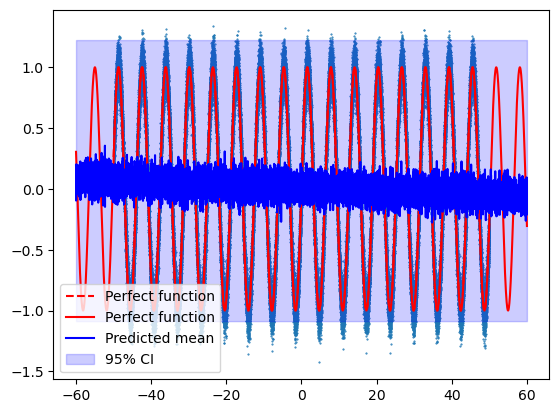

In [36]:
y_pred_mean = engressor.predict(x_eval, target="mean").cpu().detach().numpy() ## for the conditional mean
y_pred_med = engressor.predict(x_eval, target="median").cpu().detach().numpy() ## for the conditional median
y_pred_quant = engressor.predict(x_eval, target=[0.025, 0.5, 0.975]) ## for the conditional 2.5% and 97.5% quantiles

plt.scatter(x, y, marker='.', s=1)
plt.plot(x, y_perfect, color='red', linestyle='dashed', label='Perfect function')
plt.plot(x_eval, y_eval_perfect, color='red', label='Perfect function')
plt.plot(x_eval, y_pred_mean, color='blue', label='Predicted mean')
plt.fill_between(x_eval, y_pred_quant[0][0].cpu().detach().numpy(), y_pred_quant[2][0].cpu().detach().numpy(), color='blue', alpha=0.2, label='95% CI')
plt.legend()
plt.show()

In [39]:
import stable_baselines3 as sb3
from stable_baselines3.common.env_util import make_vec_env
import gymnasium as gym

env = make_vec_env("CartPole-v1", n_envs=1)
model = sb3.PPO("MlpPolicy", env, verbose=1, device=device)
model.learn(total_timesteps=10_000)

obs = env.reset()
for _ in range(1000):
    action, _states = model.predict(obs, deterministic=True)
    obs, rewards, dones, info = env.step(action)
    env.render()

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21.4     |
|    ep_rew_mean     | 21.4     |
| time/              |          |
|    fps             | 1080     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26.2        |
|    ep_rew_mean          | 26.2        |
| time/                   |             |
|    fps                  | 878         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008665331 |
|    clip_fraction        | 0.101       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | 0.0082      |
|    learnin

error: XDG_RUNTIME_DIR is invalid or not set in the environment.


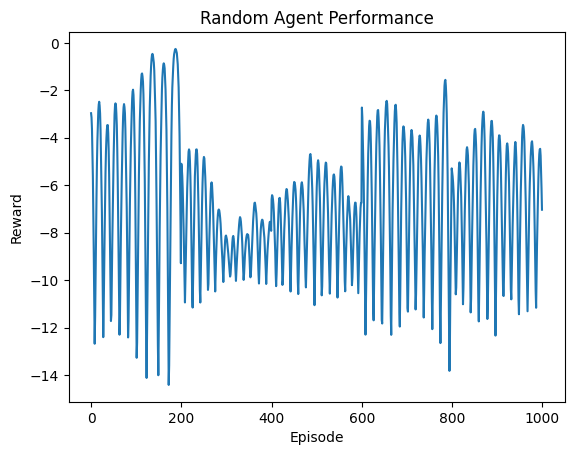

In [19]:

import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("Pendulum-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

rewards = []
for _ in range(1000):
    # env.render()
    action = env.action_space.sample()  
    observation, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

    if terminated or truncated:
        observation, info = env.reset()

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Random Agent Performance")
plt.show()

Episode 10/120, avg reward (last 10): -1088.43
Episode 20/120, avg reward (last 10): -790.19
Episode 30/120, avg reward (last 10): -913.12
Episode 40/120, avg reward (last 10): -999.33
Episode 50/120, avg reward (last 10): -932.85
Episode 60/120, avg reward (last 10): -703.27
Episode 70/120, avg reward (last 10): -720.44
Episode 80/120, avg reward (last 10): -693.55
Episode 90/120, avg reward (last 10): -925.44
Episode 100/120, avg reward (last 10): -1147.41
Episode 110/120, avg reward (last 10): -1502.58
Episode 120/120, avg reward (last 10): -1006.37


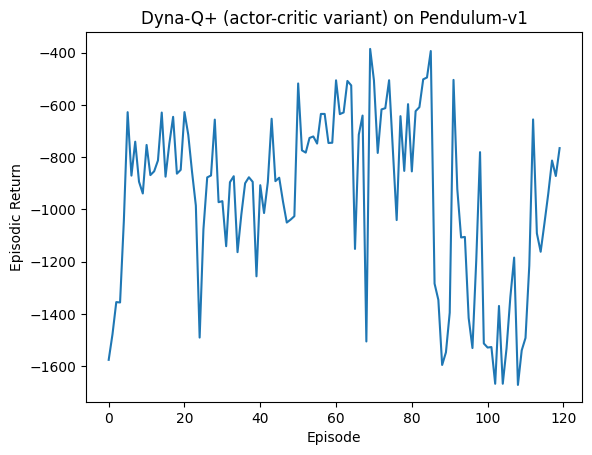

In [21]:
# dyna_q_plus_pendulum.py
import random
import collections
import numpy as np
import torch
from torch import nn, optim
import torch.nn.functional as F
import gymnasium as gym
import math
import matplotlib.pyplot as plt

# -------------------------
# Model classes (fixed)
# -------------------------
class QNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa).squeeze(-1)  # return shape (batch,)

class PNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=128):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, state_dim),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)

class RNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2 * state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action, next_state):
        x = torch.cat([state, action, next_state], dim=-1)
        return self.model(x).squeeze(-1)

class PiNet(nn.Module):
    def __init__(self, state_dim, action_dim, dim=64, action_scale=2.0):
        super().__init__()
        self.action_scale = action_scale
        self.net = nn.Sequential(
            nn.Linear(state_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, action_dim),
        )

    def forward(self, state):
        # map outputs to [-action_scale, action_scale]
        raw = self.net(state)
        return torch.tanh(raw) * self.action_scale

# -------------------------
# Replay / Model Buffer
# -------------------------
# We'll keep a buffer of real transitions for training, and a "model memory"
# for planning updates storing (state, action, next_state, reward, last_seen_time).
Transition = collections.namedtuple("Transition", ["s","a","s2","r","t"])

class ModelMemory:
    def __init__(self):
        self.data = []  # list of Transition
    def add(self, s, a, s2, r, t):
        self.data.append(Transition(s,a,s2,r,t))
    def sample(self, n):
        return random.sample(self.data, min(n, len(self.data)))
    def __len__(self):
        return len(self.data)

# -------------------------
# DynaQ+ agent
# -------------------------
class DynaQPlus:
    def __init__(self, env,
                 gamma=0.99,
                 alpha_q=1e-3,
                 alpha_model=1e-3,
                 alpha_pi=1e-4,
                 planning_steps=50,
                 kappa=1e-3,
                 batch_size=64,
                 device='cpu'):

        self.env = env
        self.device = device
        self.gamma = gamma
        self.planning_steps = planning_steps
        self.kappa = kappa
        self.batch_size = batch_size

        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.shape[0]
        # action range (Pendulum is -2..2)
        self.action_high = float(env.action_space.high[0])
        self.action_low = float(env.action_space.low[0])

        # models
        self.Q = QNet(self.state_dim, self.action_dim).to(self.device)
        self.P = PNet(self.state_dim, self.action_dim).to(self.device)
        self.R = RNet(self.state_dim, self.action_dim).to(self.device)
        self.Pi = PiNet(self.state_dim, self.action_dim, action_scale=self.action_high).to(self.device)

        # opts
        self.q_opt = optim.Adam(self.Q.parameters(), lr=alpha_q)
        self.p_opt = optim.Adam(self.P.parameters(), lr=alpha_model)
        self.r_opt = optim.Adam(self.R.parameters(), lr=alpha_model)
        self.pi_opt = optim.Adam(self.Pi.parameters(), lr=alpha_pi)

        # replay buffers
        self.real_buffer = []   # store raw real transitions for minibatch training of models and Q
        self.model_mem = ModelMemory()  # model memory with timestamps for Dyna planning
        self.time = 0

    def select_action(self, state, noise_scale=0.1):
        s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            a = self.Pi(s).cpu().numpy()[0]
        # add small exploration noise in behaviour
        a = a + noise_scale * np.random.randn(*a.shape)
        return np.clip(a, self.action_low, self.action_high)

    def store_real(self, s, a, s2, r):
        self.real_buffer.append((s, a, s2, r))
        self.time += 1
        # store into model memory with current timestamp for planning
        self.model_mem.add(np.array(s), np.array(a), np.array(s2), float(r), int(self.time))

    def train_models(self, epochs=1):
        if len(self.real_buffer) < 8:
            return
        for _ in range(epochs):
            batch = random.sample(self.real_buffer, min(len(self.real_buffer), self.batch_size))
            s_b = torch.tensor(np.array([b[0] for b in batch]), dtype=torch.float32, device=self.device)
            a_b = torch.tensor(np.array([b[1] for b in batch]), dtype=torch.float32, device=self.device)
            s2_b = torch.tensor(np.array([b[2] for b in batch]), dtype=torch.float32, device=self.device)
            r_b = torch.tensor(np.array([b[3] for b in batch]), dtype=torch.float32, device=self.device)

            # dynamics loss
            pred_s2 = self.P(s_b, a_b)
            loss_p = F.mse_loss(pred_s2, s2_b)
            self.p_opt.zero_grad(); loss_p.backward(); self.p_opt.step()

            # reward loss
            pred_r = self.R(s_b, a_b, s2_b)
            loss_r = F.mse_loss(pred_r, r_b)
            self.r_opt.zero_grad(); loss_r.backward(); self.r_opt.step()

    def critic_update(self, s, a, r, s2):
        # s,a,s2 are numpy arrays or tensors convertible
        s_t = torch.tensor(np.array(s), dtype=torch.float32, device=self.device).unsqueeze(0)
        a_t = torch.tensor(np.array(a), dtype=torch.float32, device=self.device).unsqueeze(0)
        s2_t = torch.tensor(np.array(s2), dtype=torch.float32, device=self.device).unsqueeze(0)
        r_t = torch.tensor(float(r), dtype=torch.float32, device=self.device).unsqueeze(0)

        with torch.no_grad():
            a_next = self.Pi(s2_t)
            q_next = self.Q(s2_t, a_next)
            target = r_t + self.gamma * q_next

        q_val = self.Q(s_t, a_t)
        loss_q = F.mse_loss(q_val, target)

        self.q_opt.zero_grad()
        loss_q.backward()
        self.q_opt.step()
        return loss_q.item()

    def policy_update(self, states_batch):
        # states_batch: list or array of states
        s_b = torch.tensor(np.array(states_batch), dtype=torch.float32, device=self.device)
        a_pred = self.Pi(s_b)
        # objective: maximize Q(s, Pi(s)) -> minimize negative
        q_vals = self.Q(s_b, a_pred)
        # we maximize mean q, so minimize -mean(q)
        loss_pi = - q_vals.mean()

        self.pi_opt.zero_grad()
        loss_pi.backward()
        self.pi_opt.step()
        return loss_pi.item()

    def planning_updates(self, n_planning):
        # sample from model memory, compute exploration-bonus augmented reward,
        # use predicted next state and reward from learned models for planning updates
        if len(self.model_mem) == 0:
            return
        for _ in range(n_planning):
            tran = random.choice(self.model_mem.data)
            s = tran.s
            a = tran.a
            t_last = tran.t
            # compute bonus
            delta_t = max(1, self.time - t_last)
            bonus = self.kappa * math.sqrt(delta_t)

            s_t = torch.tensor(s, dtype=torch.float32, device=self.device).unsqueeze(0)
            a_t = torch.tensor(a, dtype=torch.float32, device=self.device).unsqueeze(0)
            # predict next state & reward from model
            with torch.no_grad():
                s2_pred = self.P(s_t, a_t)
                r_pred = self.R(s_t, a_t, s2_pred)
            # augmented reward
            r_aug = (r_pred + bonus).detach().cpu().numpy().item()
            # do a critic update using (s,a,r_aug,s2_pred)
            # convert s2_pred back to numpy for critic_update convenience
            s2_np = s2_pred.detach().cpu().numpy()[0]
            self.critic_update(s, a, r_aug, s2_np)

    def train(self, num_episodes=200, max_steps=200,
              initial_random_steps=500, model_epochs=1, print_every=10,
              noise_scale=0.2):

        episode_rewards = []
        obs, _ = self.env.reset(seed=42)

        # bootstrap with some random interactions
        for _ in range(initial_random_steps):
            a = self.env.action_space.sample()
            s2, r, done, term, info = self.env.step(a)
            self.store_real(obs, a, s2, r)
            obs = s2
            if done or term:
                obs, _ = self.env.reset()

        for ep in range(num_episodes):
            obs, _ = self.env.reset()
            total_r = 0.0
            for t in range(max_steps):
                a = self.select_action(obs, noise_scale=noise_scale)
                s2, r, done, term, info = self.env.step(a)
                total_r += r
                # store
                self.store_real(obs, a, s2, r)

                # 1) train models on real data
                self.train_models(epochs=model_epochs)

                # 2) real critic update (one step)
                self.critic_update(obs, a, r, s2)

                # 3) policy update (use a minibatch of recent states)
                # sample states for policy update (if not enough, use latest)
                if len(self.real_buffer) >= self.batch_size:
                    states_batch = [x[0] for x in random.sample(self.real_buffer, self.batch_size)]
                else:
                    states_batch = [x[0] for x in self.real_buffer]
                _ = self.policy_update(states_batch)

                # 4) planning (Dyna-Q+ updates)
                self.planning_updates(self.planning_steps)

                obs = s2
                if done or term:
                    break

            episode_rewards.append(total_r)
            if (ep + 1) % print_every == 0:
                print(f"Episode {ep+1}/{num_episodes}, avg reward (last {print_every}): {np.mean(episode_rewards[-print_every:]):.2f}")

        return episode_rewards

# -------------------------
# Example usage
# -------------------------
if __name__ == "__main__":
    env = gym.make("Pendulum-v1")
    agent = DynaQPlus(env,
                      gamma=0.98,
                      alpha_q=1e-3,
                      alpha_model=1e-3,
                      alpha_pi=1e-4,
                      planning_steps=30,
                      kappa=1e-3,
                      batch_size=64,
                      device='cpu')
    rewards = agent.train(num_episodes=120, max_steps=200,
                          initial_random_steps=400, model_epochs=2, print_every=10, noise_scale=0.15)

    plt.plot(rewards)
    plt.xlabel("Episode")
    
    plt.ylabel("Episodic Return")
    plt.title("Dyna-Q+ (actor-critic variant) on Pendulum-v1")
    plt.show()


In [ ]:
import torch
from torch import nn, optim
import torch.functional as F


class Q(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(Q, self).__init__()
        self.model = nn.Sequential(
            # q(s, a) -> value
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)
    

class P(nn.Module):
    def __init__(self, state_dim, action_dim, dim=32):
        super(P, self).__init__()
        self.model = nn.Sequential(
            # p(s, a) -> s'
            nn.Linear(state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, state_dim),
        )

    def forward(self, state, action):
        sa = torch.cat([state, action], dim=-1)
        return self.model(sa)


class R(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(R, self).__init__()
        self.model = nn.Sequential(
            # r(s, a, s') -> reward
            nn.Linear(2 * state_dim + action_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, 1),
        )

    def forward(self, state, action, next_state):
        sa_next = torch.cat([state, action, next_state], dim=-1)
        return self.model(sa_next)


class Pi(nn.Module):
    def __init__(self, state_dim, action_dim, dim=16):
        super(Pi, self).__init__()
        self.model = nn.Sequential(
            # pi(s) -> a
            nn.Linear(state_dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, action_dim),
            nn.Tanh() * 2,  # Assuming action space is normalized between -2 and 2
        )

    def forward(self, state):
        return self.model(state)


class DynaQplus():
    
    def __init__(self, env, steps, planning_steps, alpha, gamma, epsilon, kappa):
        super(DynaQplus, self).__init__()
        self.env = env
        self.steps = steps
        self.planning_steps = planning_steps
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.kappa = kappa

        self.state_dim = env.observation_space.shape[0]
        self.action_dim = env.action_space.shape[0]

        self._init_Q_func()
        self._init_dynamics_model()
        self._init_reward_model()

    def _init_Q_func(self, dim=16):
        '''initialize a MLP for Q function'''
        self.Q = Q(self.state_dim, self.action_dim, dim)
        self.Q_optim = optim.Adam(self.Q.parameters(), lr=1e-3)

    def _init_dynamics_model(self, dim=32):
        '''initialize a MLP for dynamics model'''
        self.P = P(self.state_dim, self.action_dim, dim)
        self.P_optim = optim.Adam(self.P.parameters(), lr=1e-3)

    def _init_reward_model(self, dim=16):
        '''initialize a MLP for reward model'''
        self.R = R(self.state_dim, self.action_dim, dim)
        self.R_optim = optim.Adam(self.R.parameters(), lr=1e-3)

    def _init_policy(self, dim=16):
        '''initialize a MLP for policy'''
        self.Pi = Pi(self.state_dim, self.action_dim, dim)
        self.Pi_optim = optim.Adam(self.Pi.parameters(), lr=1e-3)

    def policy(self, state, samples=10):
        '''epsilon-greedy policy'''
        if torch.rand(1).item() < self.epsilon:
            return self.env.action_space.sample()
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad(): # prevent gradients
                action = self.Pi(state_tensor)
            return action.squeeze(0).numpy()
        

    
    def train(self, episodes=100):
        loss_dict = {'Q': [], 'P': [], 'R': [], 'Pi': []}
        for episode in range(episodes):
            state, info = self.env.reset()
            total_reward = 0
            for step in range(self.steps):
                action = self.policy(state)
                next_state, reward, terminated, truncated, info = self.env.step(action)
                total_reward += reward
                # update Q function
                with torch.no_grad():
                    q_now = self.Q(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                   torch.tensor(action, dtype=torch.float32).unsqueeze(0))
                    q_next = self.Q(torch.tensor(next_state, dtype=torch.float32).unsqueeze(0),
                                    self.Pi(torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)))        
                    target = q_now + self.alpha * (reward + self.gamma * q_next - q_now)
                    loss = nn.MSELoss()(q_now, target)
                self.Q_optim.zero_grad()
                loss.backward()
                self.Q_optim.step()
                loss_dict['Q'].append(loss.item())

                # update dynamics model
                with torch.no_grad():
                    pred_next_state = self.P(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                             torch.tensor(action, dtype=torch.float32).unsqueeze(0))
                    loss = nn.MSELoss()(pred_next_state, torch.tensor(next_state, dtype=torch.float32).unsqueeze(0))
                self.P_optim.zero_grad()
                loss.backward()
                self.P_optim.step()
                loss_dict['P'].append(loss.item())
                
                # update reward model
                with torch.no_grad():
                    pred_reward = self.R(torch.tensor(state, dtype=torch.float32).unsqueeze(0),
                                         torch.tensor(action, dtype=torch.float32).unsqueeze(0),
                                         torch.tensor(next_state, dtype=torch.float32).unsqueeze(0))
                    loss = nn.MSELoss()(pred_reward, torch.tensor(reward, dtype=torch.float32).unsqueeze(0).unsqueeze(0))
                self.R_optim.zero_grad()
                loss.backward()
                self.R_optim.step()
                loss_dict['R'].append(loss.item())

                # # update policy
                # with torch.no_grad():

                state = next_state
                if terminated or truncated:
                    break
            print(f"Episode {episode+1}, Total Reward: {total_reward}")




In [18]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ===== 1. Dynamics Model (World Model) =====
class DynamicsModel(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        return self.model(x)


# ===== 2. Collect real data =====
def collect_data(env, policy, episodes=10, max_steps=200):
    data = []
    for _ in range(episodes):
        obs, _ = env.reset()
        for _ in range(max_steps):
            action = policy(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            data.append((obs, action, next_obs, reward))
            obs = next_obs
            if terminated or truncated:
                break
    return data


# ===== 3. Train world model =====
def train_world_model(model, data, epochs=30, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    states = torch.tensor(np.array([d[0] for d in data]), dtype=torch.float32)
    actions = torch.tensor(np.array([d[1] for d in data]), dtype=torch.float32)
    next_states = torch.tensor(np.array([d[2] for d in data]), dtype=torch.float32)

    for epoch in range(epochs):
        pred_next = model(states, actions)
        loss = loss_fn(pred_next, next_states)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


# ===== 4. MPC Planner (Random Shooting) =====
def plan_action(model, state, horizon=20, n_candidates=100, action_low=-2.0, action_high=2.0):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

    best_return = -1e9
    best_action = None

    for _ in range(n_candidates):
        # sample candidate sequences with correct action dimension
        actions = np.random.uniform(action_low, action_high, size=(horizon, action_dim))
        total_reward = 0.0
        s = state_tensor.clone()

        # Simulate rollout in learned model
        for a in actions:
            # ensure a is shape (1, action_dim) and float32
            a_np = np.asarray(a, dtype=np.float32).reshape(1, action_dim)
            a_tensor = torch.from_numpy(a_np)
            s = model(s, a_tensor)
            # simple reward approximation (cos(theta)-cost)
            theta_cos = s[0, 0]
            theta_dot = s[0, 2]
            # use scalar value for action cost
            a_val = float(a_np.ravel()[0])
            reward = theta_cos - 0.1 * (theta_dot**2) - 0.001 * (a_val**2)
            total_reward += reward.item()

        if total_reward > best_return:
            best_return = total_reward
            best_action = actions[0]

    return np.clip(best_action, action_low, action_high)


# ===== 5. Main training loop =====
env = gym.make("Pendulum-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

# Initialize world model
model = DynamicsModel(state_dim, action_dim)

# Initial random data collection
buffer = collect_data(env, policy=lambda obs: env.action_space.sample(), episodes=20)

rewards_per_iter = []

for iteration in range(15):  # 15 model-based iterations
    print(f"=== Iteration {iteration} ===")
    # Collect data using MPC with learned model
    rewards = []
    for ep in range(5):
        obs, _ = env.reset()
        ep_reward = 0
        prev_obs = None
        for t in range(200):
            prev_obs = obs.copy()
            action = plan_action(model, obs, horizon=20, n_candidates=200)
            # action is a numpy array of shape (action_dim,), pass it directly
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
        # store the last transition properly: (state, action, next_state, reward)
        if prev_obs is not None:
            buffer.append((prev_obs, action, obs, reward))
            break
        rewards.append(ep_reward)
        buffer.append((obs, [action], obs, reward))  # store last transition
    avg_reward = np.mean(rewards)
    rewards_per_iter.append(avg_reward)
    print(f"Average reward: {avg_reward:.2f}")

env.close()

# ===== 6. Plot Learning Curve =====
plt.plot(rewards_per_iter)
plt.xlabel("Model-Based Iteration")
plt.ylabel("Average Return")
plt.title("MBRL on Pendulum (Random Shooting MPC)")
plt.grid()
plt.show()


=== Iteration 0 ===
Average reward: -1303.36
=== Iteration 1 ===
Average reward: -1126.15
=== Iteration 2 ===
Average reward: -1150.45
=== Iteration 3 ===
Average reward: -1305.00
=== Iteration 4 ===


KeyboardInterrupt: 

In [ ]:

def dynaQplus():
